In [33]:
# ==========================================
# 📦 CELL 1 — SETUP & PATH VERIFICATION
# ==========================================

import os
from zipfile import ZipFile
from google.colab import drive

# ✅ Mount Google Drive
drive.mount('/content/drive')

# ✅ Define dataset zip and extraction path
zip_path = "/content/drive/MyDrive/KL and Ahlback.zip"
extract_path = "/content/data"

# ✅ Unzip only if not already extracted
if not os.path.exists(os.path.join(extract_path, "KL and Ahlback")):
    with ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
        print("✅ Dataset extracted successfully!")
else:
    print("✅ Dataset already extracted.")

# ✅ Show directory structure
base_dir = os.path.join(extract_path, "KL and Ahlback")
for split in ["train", "val", "test", "auto_test"]:
    split_dir = os.path.join(base_dir, split)
    if os.path.exists(split_dir):
        subfolders = [f.name for f in os.scandir(split_dir) if f.is_dir()]
        print(f"\n📁 {split_dir} → {len(subfolders)} class folders")
        for sf in subfolders:
            img_count = len(os.listdir(os.path.join(split_dir, sf)))
            print(f"   {sf:<6} → {img_count} images")
    else:
        print(f"⚠️  Missing folder: {split_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset already extracted.

📁 /content/data/KL and Ahlback/train → 5 class folders
   4_5    → 173 images
   3_4    → 757 images
   0_1    → 2286 images
   2_3    → 1516 images
   1_2    → 1046 images

📁 /content/data/KL and Ahlback/val → 5 class folders
   4_5    → 27 images
   3_4    → 106 images
   0_1    → 328 images
   2_3    → 212 images
   1_2    → 153 images

📁 /content/data/KL and Ahlback/test → 5 class folders
   4_5    → 51 images
   3_4    → 223 images
   0_1    → 639 images
   2_3    → 447 images
   1_2    → 296 images

📁 /content/data/KL and Ahlback/auto_test → 5 class folders
   4_5    → 44 images
   3_4    → 200 images
   0_1    → 604 images
   2_3    → 403 images
   1_2    → 275 images


In [34]:
# ==========================================
# 🧠 CELL 2 — CLAHE PREPROCESSING + TRANSFORMS
# ==========================================

import cv2
import numpy as np
from PIL import Image
from torchvision import transforms

# ✅ CLAHE (Contrast Limited Adaptive Histogram Equalization)
class CLAHETransform:
    def __init__(self, clipLimit=2.0, tileGridSize=(8,8)):
        self.clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)

    def __call__(self, img):
        # Convert to grayscale
        img = np.array(img.convert("L"))
        # Apply CLAHE
        img = self.clahe.apply(img)
        # Stack to 3 channels
        img = cv2.merge([img, img, img])
        return Image.fromarray(img)

# ✅ Data augmentation strategy
train_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    CLAHETransform(),
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("✅ CLAHE preprocessing & transforms ready.")


✅ CLAHE preprocessing & transforms ready.


In [35]:
# ==========================================
# 📊 CELL 3 — DATASET + WEIGHTED SAMPLER + CLASS MAPPING
# ==========================================

import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets
import numpy as np

# ✅ Dataset paths
base_dir = "/content/data/KL and Ahlback"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# ✅ Create datasets with CLAHE preprocessing
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transform)

# ✅ Class mapping (from folder names)
class_map = train_dataset.classes
print("Detected classes:", class_map)

# ✅ Compute per-class counts for balancing
class_counts = []
for class_name in class_map:
    class_path = os.path.join(train_dir, class_name)
    class_counts.append(len(os.listdir(class_path)))

total_samples = sum(class_counts)
class_weights = [total_samples / c for c in class_counts]
samples_weight = [class_weights[label] for label in train_dataset.targets]
sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

# ✅ DataLoaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ✅ Class distribution print
print("\n📊 Class distribution (train):")
for i, (cls, count) in enumerate(zip(class_map, class_counts)):
    perc = (count / total_samples) * 100
    print(f"  {cls:<6} → {count:4d} images ({perc:.1f}%)")

print("\n✅ WeightedRandomSampler applied successfully!")
print(f"📦 Batch size = {BATCH_SIZE}")

# ✅ Grade label ranges for clarity
print("\nKL grades range: 0–4")
print("Ahlbäck grades range: 1–5 ✅")


Detected classes: ['0_1', '1_2', '2_3', '3_4', '4_5']

📊 Class distribution (train):
  0_1    → 2286 images (39.6%)
  1_2    → 1046 images (18.1%)
  2_3    → 1516 images (26.2%)
  3_4    →  757 images (13.1%)
  4_5    →  173 images (3.0%)

✅ WeightedRandomSampler applied successfully!
📦 Batch size = 16

KL grades range: 0–4
Ahlbäck grades range: 1–5 ✅


In [36]:
# ==========================================
# ⚙️ CELL 4 — HYBRID MODEL (ResNet50 + EfficientNetV2-RW-S)
# ==========================================

import timm
import torch
import torch.nn as nn

class HybridDualOutput(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, dropout=0.4):
        super(HybridDualOutput, self).__init__()

        # ✅ Backbone 1: ResNet-50
        self.resnet = timm.create_model(
            "resnet50",
            pretrained=pretrained,
            num_classes=0,     # feature extractor
            global_pool="avg"
        )

        # ✅ Backbone 2: EfficientNet V2-RW-S (fixed pretrained version)
        self.effnet = timm.create_model(
            "efficientnetv2_rw_s",  # 🧠 Re-weighted pretrained EfficientNet V2-S
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg"
        )

        res_dim = self.resnet.num_features
        eff_dim = self.effnet.num_features
        fusion_dim = res_dim + eff_dim  # 2048 + 1280 = 3328

        # ✅ Fusion Layer
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # ✅ Dual Output Heads
        self.fc_kl = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

        self.fc_ahl = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        res_feat = self.resnet(x)
        eff_feat = self.effnet(x)
        fused = torch.cat((res_feat, eff_feat), dim=1)
        fused = self.fusion(fused)
        kl_out = self.fc_kl(fused)
        ahl_out = self.fc_ahl(fused)
        return kl_out, ahl_out


# ✅ Instantiate Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridDualOutput(num_classes=5, pretrained=True).to(device)

print(f"✅ Hybrid model ready on: {device}")
print(f"ResNet output: {model.resnet.num_features}, EfficientNetV2-RW-S output: {model.effnet.num_features}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")


✅ Hybrid model ready on: cuda
ResNet output: 2048, EfficientNetV2-RW-S output: 1792
Total parameters: 50.65 M


In [37]:
# ==========================================
# ⚙️ CELL 5 — TRAINING ENGINE (Advanced Augmentations + 15 Epochs)
# ==========================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from tqdm import tqdm
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import time, random

# ======================================================
# ⚙️ DATA AUGMENTATION PIPELINE (using Albumentations)
# ======================================================
train_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.4),
    A.ElasticTransform(alpha=50, sigma=5, alpha_affine=20, p=0.4),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.Resize(384, 384),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Custom Dataset for Albumentations
class AlbDataset(torch.utils.data.Dataset):
    def __init__(self, folder, transform=None):
        self.data = datasets.ImageFolder(folder)
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.data[idx]
        image_np = np.array(img)
        if self.transform:
            image_np = self.transform(image=image_np)["image"]
        return image_np, label

    def __len__(self):
        return len(self.data)

# Paths
data_dir = "/content/data/KL and Ahlback"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")

train_dataset = AlbDataset(train_dir, transform=train_transform)
val_dataset = AlbDataset(val_dir, transform=val_transform)
class_map = train_dataset.data.classes

# ======================================================
# ⚖️ Weighted Sampler for Imbalance Handling
# ======================================================
class_counts = [len(os.listdir(os.path.join(train_dir, c))) for c in class_map]
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [weights[label] for _, label in train_dataset.data.imgs]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4)

print(f"📊 Train Samples: {len(train_dataset)}, Val Samples: {len(val_dataset)}")
print(f"⚖️ Class balance: {class_counts}")

# ======================================================
# 🧠 Training Config
# ======================================================
EPOCHS = 15
LR = 3e-4
WEIGHT_DECAY = 1e-4
EMA_DECAY = 0.999
SAVE_PATH = "/content/drive/MyDrive/Best_Hybrid_Model_Final_75_duong.pth"
patience = 3

criterion_kl = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion_ahl = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1)
scaler = torch.cuda.amp.GradScaler()

# EMA tracking
class EMA:
    def __init__(self, model, decay):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}
    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                if v.dtype.is_floating_point:
                    self.shadow[k] -= (1 - self.decay) * (self.shadow[k] - v.detach())
    def apply_shadow(self, model):
        self.backup = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(self.shadow)
    def restore(self, model):
        model.load_state_dict(self.backup)

ema = EMA(model, EMA_DECAY)

# ======================================================
# 🚀 TRAINING LOOP
# ======================================================
best_val_acc, best_kl, best_ahl = 0, 0, 0
wait = 0
train_losses_all, val_losses_all = [], []
kl_acc_all, ahl_acc_all = [], []

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    model.train()
    total_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", unit="batch")

    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
        ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            kl_out, ahl_out = model(imgs)
            loss_kl = criterion_kl(kl_out, kl_labels)
            loss_ahl = criterion_ahl(ahl_out, ahl_labels)
            loss = loss_kl + loss_ahl

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        total_loss += loss.item() * imgs.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = total_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    ema.apply_shadow(model)
    val_loss, kl_correct, ahl_correct = 0.0, 0, 0
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc="Validating", leave=False)
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
            ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)

            with torch.cuda.amp.autocast():
                kl_out, ahl_out = model(imgs)
                loss_kl = criterion_kl(kl_out, kl_labels)
                loss_ahl = criterion_ahl(ahl_out, ahl_labels)
                loss = loss_kl + loss_ahl

            val_loss += loss.item() * imgs.size(0)
            kl_correct += (kl_out.argmax(1) == kl_labels).sum().item()
            ahl_correct += (ahl_out.argmax(1) == ahl_labels).sum().item()

    avg_val_loss = val_loss / len(val_loader.dataset)
    kl_acc = kl_correct / len(val_loader.dataset)
    ahl_acc = ahl_correct / len(val_loader.dataset)
    ema.restore(model)
    scheduler.step()

    avg_val_acc = (kl_acc + ahl_acc) / 2
    elapsed = time.time() - start

    # Save by dual-metric (KL or Ahl improvement)
    if avg_val_acc > best_val_acc or kl_acc > best_kl or ahl_acc > best_ahl:
        best_val_acc = avg_val_acc
        best_kl = max(best_kl, kl_acc)
        best_ahl = max(best_ahl, ahl_acc)
        ema.apply_shadow(model)
        torch.save(model.state_dict(), SAVE_PATH)
        ema.restore(model)
        print(f"\n💾 Best model saved at epoch {epoch} (KL={kl_acc:.3f}, Ahl={ahl_acc:.3f}, Avg={avg_val_acc*100:.2f}%)")
        wait = 0
    else:
        wait += 1

    print(f"Epoch[{epoch}/{EPOCHS}] | Train={avg_train_loss:.4f} | Val={avg_val_loss:.4f} | "
          f"KL={kl_acc:.3f} | Ahl={ahl_acc:.3f} | Time={elapsed:.1f}s")

    train_losses_all.append(avg_train_loss)
    val_losses_all.append(avg_val_loss)
    kl_acc_all.append(kl_acc)
    ahl_acc_all.append(ahl_acc)

    if wait >= patience:
        print(f"⏹ Early stopping triggered at epoch {epoch}")
        break

print("\n✅ Training complete!")
print(f"📁 Best model saved to: {SAVE_PATH}")


/tmp/ipython-input-430122925.py:25: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=50, sigma=5, alpha_affine=20, p=0.4),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/tmp/ipython-input-430122925.py:95: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradSca

📊 Train Samples: 5778, Val Samples: 826
⚖️ Class balance: [2286, 1046, 1516, 757, 173]


Epoch 1/15:   0%|          | 0/362 [00:00<?, ?batch/s]/tmp/ipython-input-430122925.py:135: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Validating:   0%|          | 0/52 [00:00<?, ?it/s]/tmp/ipython-input-430122925.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



💾 Best model saved at epoch 1 (KL=0.201, Ahl=0.119, Avg=15.98%)
Epoch[1/15] | Train=2.4568 | Val=3.2094 | KL=0.201 | Ahl=0.119 | Time=189.9s


Epoch 2/15: 100%|██████████| 362/362 [02:55<00:00,  2.07batch/s, loss=2.1045]


...


💾 Best model saved at epoch 13 (KL=0.700, Ahl=0.703, Avg=70.16%)
Epoch[13/15] | Train=1.6049 | Val=1.8647 | KL=0.700 | Ahl=0.703 | Time=181.3s


Epoch 14/15: 100%|██████████| 362/362 [02:51<00:00,  2.11batch/s, loss=2.1026]


Epoch[14/15] | Train=1.4986 | Val=1.8620 | KL=0.697 | Ahl=0.701 | Time=180.3s


Epoch 15/15: 100%|██████████| 362/362 [02:51<00:00,  2.11batch/s, loss=1.6318]



💾 Best model saved at epoch 15 (KL=0.697, Ahl=0.706, Avg=70.16%)
Epoch[15/15] | Train=1.4261 | Val=1.8748 | KL=0.697 | Ahl=0.706 | Time=180.3s

✅ Training complete!
📁 Best model saved to: /content/drive/MyDrive/Best_Hybrid_Model_Final_75_duong.pth


In [38]:
# ==========================================
# 🔧 CELL — Phase-2 Fine-Tuning (Freeze → Unfreeze)
# ==========================================

import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision import datasets
from tqdm import tqdm
import numpy as np

# ---------- Config ----------
CHECKPOINT = "/content/drive/MyDrive/Best_Hybrid_Model_Final_75_duong.pth"  # previous best
SAVE_PATH_FT = "/content/drive/MyDrive/Best_Hybrid_Model_Finetuned.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

epochs_freeze = 3   # only heads
epochs_unfreeze = 10  # fine-tune last part
patience = 3
batch_size = 16

# ---------- Reduced (curriculum) augmentations ----------
ft_train_aug = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.3),
    A.RandomGamma(gamma_limit=(90,110), p=0.2),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.03, rotate_limit=8, p=0.3),
    A.Resize(384,384),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

ft_val_aug = A.Compose([
    A.Resize(384,384),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# Reuse AlbDataset class if available; otherwise define it (same as earlier)
class AlbDataset(torch.utils.data.Dataset):
    def __init__(self, folder, transform=None):
        self.data = datasets.ImageFolder(folder)
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.data[idx]
        image_np = np.array(img)
        if self.transform:
            image_np = self.transform(image=image_np)["image"]
        return image_np, label

    def __len__(self):
        return len(self.data)

# Paths (same dataset structure)
base_dir = "/content/data/KL and Ahlback"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

# Build dataset / loader with reduced augmentations
train_dataset_ft = AlbDataset(train_dir, transform=ft_train_aug)
val_dataset_ft = AlbDataset(val_dir, transform=ft_val_aug)

class_map = train_dataset_ft.data.classes
class_counts = [len(os.listdir(os.path.join(train_dir, c))) for c in class_map]
print("Class map:", class_map)
print("Class counts:", class_counts)

# weighted sampler (again)
weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [weights[label] for _, label in train_dataset_ft.data.imgs]
sampler_ft = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader_ft = DataLoader(train_dataset_ft, batch_size=batch_size, sampler=sampler_ft, num_workers=2)
val_loader_ft = DataLoader(val_dataset_ft, batch_size=batch_size, shuffle=False, num_workers=2)

# ---------- Load model checkpoint ----------
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.to(device)
print("✅ Loaded checkpoint:", CHECKPOINT)

# ---------- Freeze all backbone params initially (only train fusion+heads) ----------
for name, p in model.named_parameters():
    if name.startswith("resnet") or name.startswith("effnet"):
        p.requires_grad = False
    else:
        p.requires_grad = True

# helper to unfreeze last pct of backbone params
def unfreeze_last_percent(model, prefix, percent=0.3):
    names = [n for n, p in model.named_parameters() if n.startswith(prefix)]
    k = max(1, int(len(names) * percent))
    to_unfreeze = set(names[-k:])
    for n, p in model.named_parameters():
        if n in to_unfreeze:
            p.requires_grad = True

# ---------- Loss: weighted cross-entropy + small label-smoothing ----------
# heavier weight to 0_1 and 1_2 as discussed
class_weights = torch.tensor([2.0, 1.3, 1.0, 1.0, 1.0], dtype=torch.float).to(device)
criterion_kl = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
criterion_ahl = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

# ---------- Optimizer & scheduler (will be reset between phases) ----------
def make_optimizer(lr):
    params = [p for p in model.parameters() if p.requires_grad]
    return AdamW(params, lr=lr, weight_decay=1e-4)

def make_scheduler(optim, T_0=5):
    return CosineAnnealingWarmRestarts(optim, T_0=T_0, T_mult=1)

scaler = torch.cuda.amp.GradScaler()  # keep compatible with Colab

# ---------- EMA (same as earlier) ----------
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}
    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                if v.dtype.is_floating_point:
                    self.shadow[k] -= (1 - self.decay) * (self.shadow[k] - v.detach())
    def apply_shadow(self, model):
        self.backup = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(self.shadow)
    def restore(self, model):
        model.load_state_dict(self.backup)

ema = EMA(model, decay=0.999)

# ---------- Training/Eval helpers ----------
def evaluate_on_loader(loader):
    model.eval()
    ema.apply_shadow(model)
    all_kl_true, all_kl_pred = [], []
    all_ahl_true, all_ahl_pred = [], []
    val_loss, kl_correct, ahl_correct = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
            ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)
            with torch.cuda.amp.autocast():
                kl_out, ahl_out = model(imgs)
                loss_kl = criterion_kl(kl_out, kl_labels)
                loss_ahl = criterion_ahl(ahl_out, ahl_labels)
                loss = loss_kl + loss_ahl
            val_loss += loss.item() * imgs.size(0)
            kl_preds = kl_out.argmax(1)
            ahl_preds = ahl_out.argmax(1)
            all_kl_true.extend(kl_labels.cpu().numpy())
            all_kl_pred.extend(kl_preds.cpu().numpy())
            all_ahl_true.extend(ahl_labels.cpu().numpy())
            all_ahl_pred.extend(ahl_preds.cpu().numpy())
            kl_correct += (kl_preds == kl_labels).sum().item()
            ahl_correct += (ahl_preds == ahl_labels).sum().item()
    avg_val_loss = val_loss / len(loader.dataset)
    kl_acc = kl_correct / len(loader.dataset)
    ahl_acc = ahl_correct / len(loader.dataset)
    ema.restore(model)
    return avg_val_loss, kl_acc, ahl_acc, all_kl_true, all_kl_pred, all_ahl_true, all_ahl_pred

# ---------- Phase A: train heads only ----------
opt = make_optimizer(lr=1e-4)
sched = make_scheduler(opt, T_0=5)
best_val = 0.0
best_kl, best_ahl = 0.0, 0.0
wait = 0

print("\n=== Phase A: Training fusion + heads (freeze backbones) ===")
for epoch in range(1, epochs_freeze + 1):
    t0 = time.time()
    model.train()
    total_loss = 0.0
    bar = tqdm(train_loader_ft, desc=f"[PhaseA] Epoch {epoch}/{epochs_freeze}", unit="batch")
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
        ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)

        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            kl_out, ahl_out = model(imgs)
            loss_kl = criterion_kl(kl_out, kl_labels)
            loss_ahl = criterion_ahl(ahl_out, ahl_labels)
            loss = loss_kl + loss_ahl
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        ema.update(model)

        total_loss += loss.item() * imgs.size(0)
        bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = total_loss / len(train_loader_ft.dataset)

    # validation
    avg_val_loss, kl_acc, ahl_acc, *_ = evaluate_on_loader(val_loader_ft)
    avg_val_acc = (kl_acc + ahl_acc) / 2
    sched.step()

    if avg_val_acc > best_val or kl_acc > best_kl or ahl_acc > best_ahl:
        best_val = avg_val_acc
        best_kl = max(best_kl, kl_acc)
        best_ahl = max(best_ahl, ahl_acc)
        ema.apply_shadow(model)
        torch.save(model.state_dict(), SAVE_PATH_FT)
        ema.restore(model)
        print(f"\n💾 PhaseA Best saved (KL={kl_acc:.3f}, Ahl={ahl_acc:.3f}, Avg={avg_val_acc*100:.2f}%)")
        wait = 0
    else:
        wait += 1

    print(f"[PhaseA] Epoch[{epoch}/{epochs_freeze}] Train={avg_train_loss:.4f} Val={avg_val_loss:.4f} KL={kl_acc:.3f} Ahl={ahl_acc:.3f} Time={time.time()-t0:.1f}s")
    if wait >= patience:
        print("⏹ Early stopping PhaseA")
        break

# ---------- Phase B: unfreeze last ~30% of backbone params and fine-tune ----------
print("\n=== Phase B: Unfreeze last portion of backbones & fine-tune ===")
# Unfreeze last 30% of resnet and effnet params
unfreeze_last_percent(model, "resnet", percent=0.3)
unfreeze_last_percent(model, "effnet", percent=0.3)

# re-create optimizer with new trainable params and lower LR
opt = make_optimizer(lr=1e-5)
sched = make_scheduler(opt, T_0=5)
wait = 0

for epoch in range(1, epochs_unfreeze + 1):
    t0 = time.time()
    model.train()
    total_loss = 0.0
    bar = tqdm(train_loader_ft, desc=f"[PhaseB] Epoch {epoch}/{epochs_unfreeze}", unit="batch")
    for imgs, labels in bar:
        imgs, labels = imgs.to(device), labels.to(device)
        kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
        ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)

        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            kl_out, ahl_out = model(imgs)
            loss_kl = criterion_kl(kl_out, kl_labels)
            loss_ahl = criterion_ahl(ahl_out, ahl_labels)
            loss = loss_kl + loss_ahl
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        ema.update(model)

        total_loss += loss.item() * imgs.size(0)
        bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = total_loss / len(train_loader_ft.dataset)

    # validation
    avg_val_loss, kl_acc, ahl_acc, *_ = evaluate_on_loader(val_loader_ft)
    avg_val_acc = (kl_acc + ahl_acc) / 2
    sched.step()

    if avg_val_acc > best_val or kl_acc > best_kl or ahl_acc > best_ahl:
        best_val = avg_val_acc
        best_kl = max(best_kl, kl_acc)
        best_ahl = max(best_ahl, ahl_acc)
        ema.apply_shadow(model)
        torch.save(model.state_dict(), SAVE_PATH_FT)
        ema.restore(model)
        print(f"\n💾 PhaseB Best saved (KL={kl_acc:.3f}, Ahl={ahl_acc:.3f}, Avg={avg_val_acc*100:.2f}%)")
        wait = 0
    else:
        wait += 1

    print(f"[PhaseB] Epoch[{epoch}/{epochs_unfreeze}] Train={avg_train_loss:.4f} Val={avg_val_loss:.4f} KL={kl_acc:.3f} Ahl={ahl_acc:.3f} Time={time.time()-t0:.1f}s")
    if wait >= patience:
        print("⏹ Early stopping PhaseB")
        break

print("\n✅ Fine-tuning complete!")
print("📁 Best fine-tuned model saved to:", SAVE_PATH_FT)


Class map: ['0_1', '1_2', '2_3', '3_4', '4_5']
Class counts: [2286, 1046, 1516, 757, 173]


/tmp/ipython-input-1876917584.py:119: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # keep compatible with Colab


✅ Loaded checkpoint: /content/drive/MyDrive/Best_Hybrid_Model_Final_75_duong.pth

=== Phase A: Training fusion + heads (freeze backbones) ===


[PhaseA] Epoch 1/3:   0%|          | 0/362 [00:00<?, ?batch/s]/tmp/ipython-input-1876917584.py:190: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[PhaseA] Epoch 1/3: 100%|██████████| 362/362 [01:20<00:00,  4.49batch/s, loss=0.7899]
/tmp/ipython-input-1876917584.py:151: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



💾 PhaseA Best saved (KL=0.705, Ahl=0.708, Avg=70.64%)
[PhaseA] Epoch[1/3] Train=1.0571 Val=1.6724 KL=0.705 Ahl=0.708 Time=89.6s


...

[PhaseB] Epoch[1/10] Train=1.0156 Val=1.7133 KL=0.701 Ahl=0.702 Time=101.2s


[PhaseB] Epoch 2/10: 100%|██████████| 362/362 [01:32<00:00,  3.91batch/s, loss=0.9053]


[PhaseB] Epoch[2/10] Train=1.0017 Val=1.7300 KL=0.697 Ahl=0.700 Time=100.5s


[PhaseB] Epoch 3/10: 100%|██████████| 362/362 [01:32<00:00,  3.92batch/s, loss=1.0463]


[PhaseB] Epoch[3/10] Train=0.9956 Val=1.7438 KL=0.705 Ahl=0.703 Time=100.8s
⏹ Early stopping PhaseB

✅ Fine-tuning complete!
📁 Best fine-tuned model saved to: /content/drive/MyDrive/Best_Hybrid_Model_Finetuned.pth


✅ Loaded fine-tuned model from: /content/drive/MyDrive/Best_Hybrid_Model_Finetuned.pth


Evaluating Validation Set:   0%|          | 0/52 [00:00<?, ?it/s]/tmp/ipython-input-3920673197.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating Validation Set: 100%|██████████| 52/52 [00:08<00:00,  6.31it/s]



✅ KL Accuracy: 70.70%
✅ Ahlbäck Accuracy: 70.46%

📊 KL Grade Classification Report:
              precision    recall  f1-score   support

           0      0.778     0.780     0.779       328
           1      0.446     0.510     0.476       153
           2      0.745     0.689     0.716       212
           3      0.823     0.745     0.782       106
           4      0.833     0.926     0.877        27

    accuracy                          0.707       826
   macro avg      0.725     0.730     0.726       826
weighted avg      0.716     0.707     0.710       826


📊 Ahlbäck Grade Classification Report:
              precision    recall  f1-score   support

           1      0.777     0.774     0.776       328
           2      0.441     0.510     0.473       153
           3      0.745     0.689     0.716       212
           4      0.823     0.745     0.782       106
           5      0.833     0.926     0.877        27

    accuracy                          0.705       826
   mac

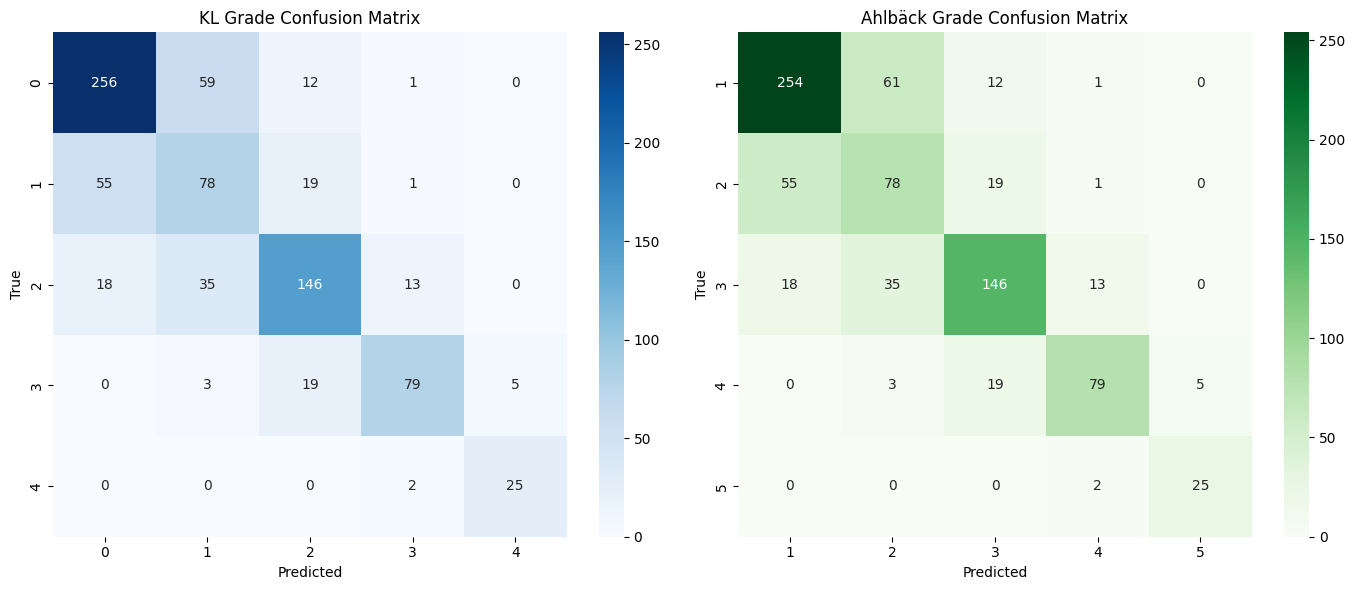

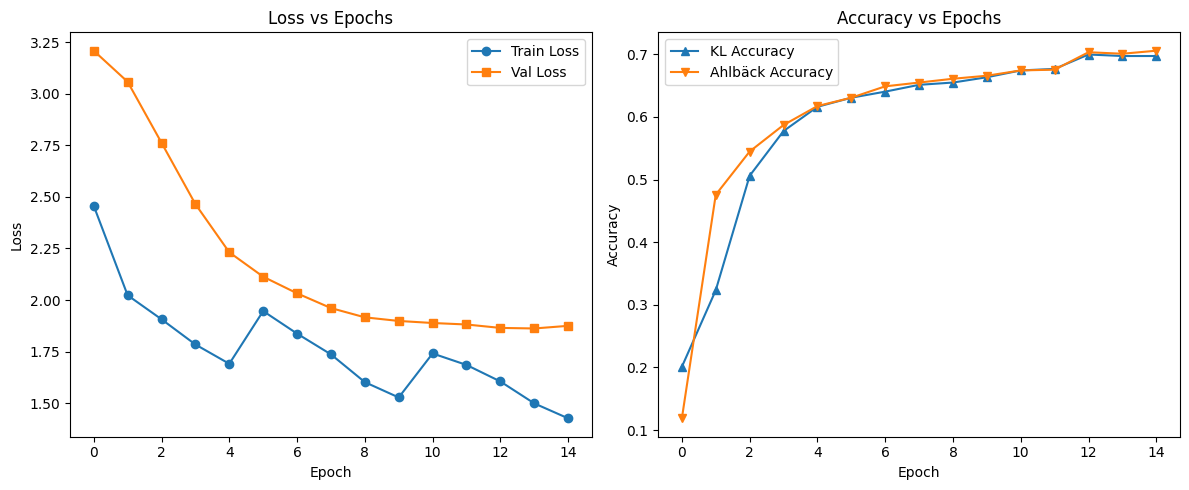

In [39]:
# ==========================================
# 📊 CELL — Evaluation & Visualization
# ==========================================
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ✅ Path to your best fine-tuned model
MODEL_PATH = "/content/drive/MyDrive/Best_Hybrid_Model_Finetuned.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print(f"✅ Loaded fine-tuned model from: {MODEL_PATH}")

# ✅ Evaluate on Validation Set
y_true_kl, y_pred_kl = [], []
y_true_ahl, y_pred_ahl = [], []

val_bar = tqdm(val_loader_ft, desc="Evaluating Validation Set")
with torch.no_grad():
    for imgs, labels in val_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
        ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)

        with torch.cuda.amp.autocast():
            kl_out, ahl_out = model(imgs)
            kl_preds = kl_out.argmax(1)
            ahl_preds = ahl_out.argmax(1)

        y_true_kl.extend(kl_labels.cpu().numpy())
        y_pred_kl.extend(kl_preds.cpu().numpy())
        y_true_ahl.extend(ahl_labels.cpu().numpy())
        y_pred_ahl.extend(ahl_preds.cpu().numpy())

# ✅ Accuracy
kl_acc = np.mean(np.array(y_true_kl) == np.array(y_pred_kl))
ahl_acc = np.mean(np.array(y_true_ahl) == np.array(y_pred_ahl))
print(f"\n✅ KL Accuracy: {kl_acc*100:.2f}%")
print(f"✅ Ahlbäck Accuracy: {ahl_acc*100:.2f}%")

# ✅ Classification Reports
print("\n📊 KL Grade Classification Report:")
print(classification_report(y_true_kl, y_pred_kl, target_names=["0","1","2","3","4"], digits=3))

print("\n📊 Ahlbäck Grade Classification Report:")
print(classification_report(y_true_ahl, y_pred_ahl, target_names=["1","2","3","4","5"], digits=3))

# ✅ Confusion Matrices
kl_cm = confusion_matrix(y_true_kl, y_pred_kl)
ahl_cm = confusion_matrix(y_true_ahl, y_pred_ahl)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(kl_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("KL Grade Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticklabels(["0","1","2","3","4"])
axes[0].set_yticklabels(["0","1","2","3","4"])

sns.heatmap(ahl_cm, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Ahlbäck Grade Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_xticklabels(["1","2","3","4","5"])
axes[1].set_yticklabels(["1","2","3","4","5"])

plt.tight_layout()
plt.show()

# ✅ Optional: Plot Loss & Accuracy Curves if available
try:
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses_all, label="Train Loss", marker="o")
    plt.plot(val_losses_all, label="Val Loss", marker="s")
    plt.title("Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(kl_acc_all, label="KL Accuracy", marker="^")
    plt.plot(ahl_acc_all, label="Ahlbäck Accuracy", marker="v")
    plt.title("Accuracy vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("ℹ️ Skipping curves plot (arrays not available in this run).")


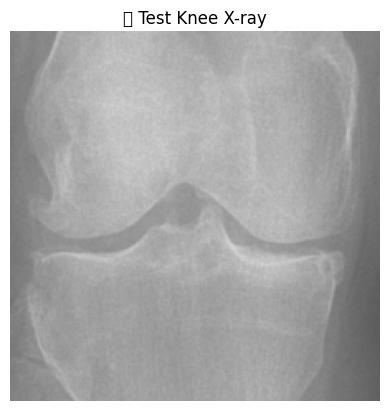


🧠 PREDICTION SUMMARY
✅ KL Grade: 2
📏 Estimated Joint Space Width: 3.00 mm
🦴 Ahlbäck Grade: 3
📉 Estimated Bone Loss: ≈ 5 mm
📖 Description: Mild bone attrition / early erosion



In [41]:
# ===============================================
# 🔍 CELL — Single Image Prediction (KL + Ahlbäck)
# ===============================================

from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch
import numpy as np

# ✅ Path to test image (update path as needed)
test_img_path = r"/content/drive/MyDrive/2_3 test image.png"

# ✅ Define preprocessing transform (consistent with training)
test_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# 🩻 Load and display image
img = Image.open(test_img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title("🦴 Test Knee X-ray")
plt.show()

# ⚙️ Prepare tensor for prediction
input_tensor = test_transform(img).unsqueeze(0).to(device)

# 🔮 Predict
model.eval()
with torch.no_grad():
    kl_out, ahl_out = model(input_tensor)
    kl_pred  = kl_out.argmax(dim=1).item()           # 0–4
    ahl_pred = ahl_out.argmax(dim=1).item() + 1      # 1–5

# ======================================================
# 📊 Mapping functions
# ======================================================

# KL → Joint Space Width (JSW in mm)
def kl_to_jsw(kl_grade):
    mapping = {
        0: 5.0,   # Normal joint space
        1: 4.0,   # Mild narrowing
        2: 3.0,   # Moderate narrowing
        3: 2.0,   # Severe narrowing
        4: 1.0    # Almost obliterated
    }
    return mapping.get(kl_grade, 2.5)

# Ahlbäck → Bone Loss (attrition) severity
def ahlback_to_boneloss(ahl_grade):
    mapping = {
        1: ("< 3 mm", "Minimal narrowing, no visible bone loss"),
        2: ("≈ 3–5 mm", "Complete cartilage loss, early bone contact"),
        3: ("≈ 5 mm", "Mild bone attrition / early erosion"),
        4: ("≈ 7 mm", "Moderate bone loss and flattening"),
        5: ("> 10 mm", "Severe bone collapse and deformity"),
    }
    return mapping.get(ahl_grade, ("–", "Undefined"))

# ======================================================
# 📢 Display Predictions
# ======================================================
predicted_jsw = kl_to_jsw(kl_pred)
bone_loss_mm, bone_loss_desc = ahlback_to_boneloss(ahl_pred)

print("\n===============================")
print("🧠 PREDICTION SUMMARY")
print("===============================")
print(f"✅ KL Grade: {kl_pred}")
print(f"📏 Estimated Joint Space Width: {predicted_jsw:.2f} mm")
print(f"🦴 Ahlbäck Grade: {ahl_pred}")
print(f"📉 Estimated Bone Loss: {bone_loss_mm}")
print(f"📖 Description: {bone_loss_desc}")
print("===============================\n")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
/tmp/ipython-input-1511119715.py:119: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
/tmp/ipython-input-1511119715.py:119: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
/tmp/ipython-input-1511119715.py:119: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=3.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

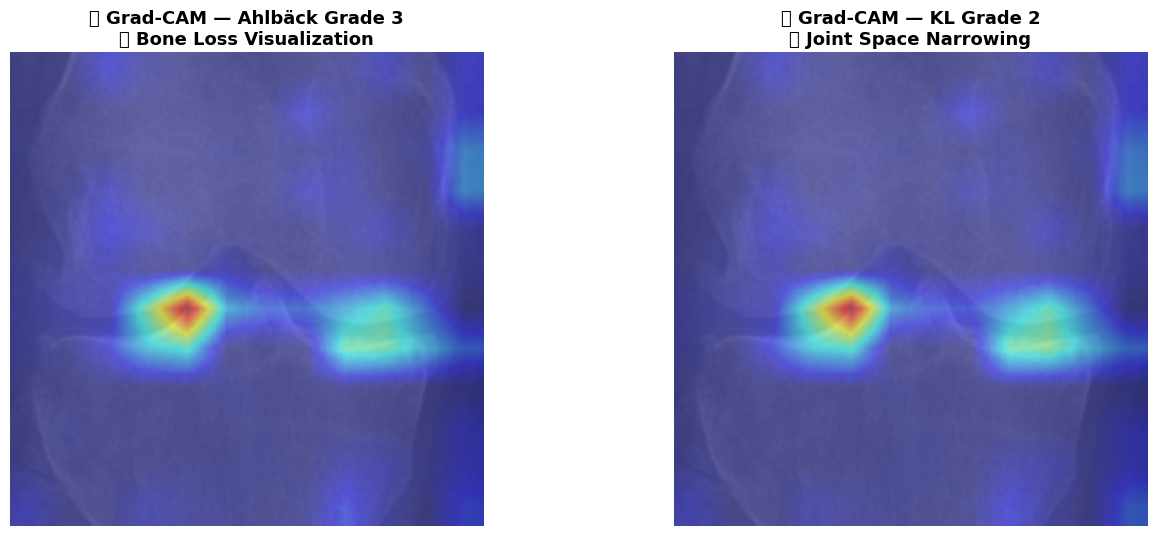

✅ Grad-CAM visualizations generated successfully!
🩻 Left → Bone loss focus (Ahlbäck)
📏 Right → Joint space narrowing (Kellgren-Lawrence)


In [42]:
# ===============================================
# 🔥 CELL — Grad-CAM Visualization (KL + Ahlbäck)
# ===============================================

import cv2
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ======================================================
# 🧠 FUNCTION: Generate Grad-CAM Heatmap
# ======================================================
def generate_gradcam(model, image_tensor, target_layer, branch="ahlback", class_index=0):
    """
    Generates Grad-CAM visualization for a specific model branch (KL or Ahlbäck).

    Args:
        model: Dual-output model (ResNet + EfficientNet hybrid)
        image_tensor: Preprocessed input image tensor
        target_layer: Layer from which gradients will be extracted
        branch: "ahlback" or "kl"
        class_index: Target class index for which Grad-CAM is generated
    """
    model.eval()
    gradients = []
    activations = []

    # ✅ Define hooks to capture forward and backward passes
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    # 🔗 Register hooks
    h_b = target_layer.register_backward_hook(backward_hook)
    h_f = target_layer.register_forward_hook(forward_hook)

    # 🧮 Forward pass
    kl_out, ahl_out = model(image_tensor)

    # 🎯 Choose which branch to visualize
    output = ahl_out if branch == "ahlback" else kl_out
    class_score = output[:, class_index]

    # 🔁 Backward pass to compute gradients
    model.zero_grad()
    class_score.backward()

    # 📊 Extract activations and gradients
    grads = gradients[0].detach()
    acts = activations[0].detach()
    pooled_grads = torch.mean(grads, dim=[0, 2, 3])

    # Weight activation maps
    for i in range(acts.shape[1]):
        acts[:, i, :, :] *= pooled_grads[i]

    # 🧩 Create Grad-CAM heatmap
    heatmap = acts.sum(dim=1).squeeze()
    heatmap = F.relu(heatmap)
    heatmap /= heatmap.max()
    heatmap = heatmap.cpu().numpy()

    # Resize & colorize
    heatmap = cv2.resize(heatmap, (384, 384))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # 🔄 Convert input tensor back to displayable image
    img = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # De-normalize
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # 💥 Overlay Grad-CAM on image
    overlayed = cv2.addWeighted(img, 0.5, heatmap_color, 0.5, 0)

    # ❎ Remove hooks to clean up
    h_b.remove()
    h_f.remove()

    return overlayed

# ======================================================
# 🎨 GENERATE GRAD-CAMs FOR BOTH OUTPUT BRANCHES
# ======================================================

# Note: Adjust target layer name according to your model
# Example for hybrid: model.resnet.layer4 or model.effnet.conv_head
target_layer = model.resnet.layer4[-1]  # Choose deep convolutional block

# 🔥 Grad-CAM for Ahlbäck (Bone Loss)
gradcam_ahlback = generate_gradcam(
    model, input_tensor, target_layer, branch="ahlback", class_index=ahl_pred - 1
)

# 🔥 Grad-CAM for KL (Joint Space Narrowing)
gradcam_kl = generate_gradcam(
    model, input_tensor, target_layer, branch="kl", class_index=kl_pred
)

# ======================================================
# 🖼️ DISPLAY BOTH HEATMAPS SIDE-BY-SIDE
# ======================================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(gradcam_ahlback, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"🔥 Grad-CAM — Ahlbäck Grade {ahl_pred}\n🦴 Bone Loss Visualization", fontsize=13, weight='bold')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(gradcam_kl, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"🔥 Grad-CAM — KL Grade {kl_pred}\n📏 Joint Space Narrowing", fontsize=13, weight='bold')

plt.tight_layout(pad=3.0)
plt.show()

# ======================================================
# 💬 Summary Output
# ======================================================
print("✅ Grad-CAM visualizations generated successfully!")
print("🩻 Left → Bone loss focus (Ahlbäck)")
print("📏 Right → Joint space narrowing (Kellgren-Lawrence)")


In [45]:
# ===============================================
# 🩺 CELL — Detailed Clinical Interpretation (KL + Ahlbäck)
# ===============================================

def describe_joint_condition(kl_grade, ahlback_grade):
    """
    Provides a detailed clinical interpretation of the predicted
    Kellgren–Lawrence (KL) and Ahlbäck grades.

    Includes:
      - Common osteoarthritis symptoms
      - Stage descriptions for KL and Ahlbäck systems
      - Recommended treatments and precautions
    """

    # ======================================================
    # 💬 Common Symptoms
    # ======================================================
    symptoms = [
        "Pain or discomfort during movement or after long periods of activity.",
        "Morning stiffness or stiffness after inactivity.",
        "Swelling or warmth around the knee joint.",
        "Crackling, grinding, or clicking sounds when moving the knee.",
        "Difficulty bending, squatting, or fully straightening the leg."
    ]

    # ======================================================
    # 🩻 Kellgren–Lawrence (KL) Grading Descriptions (0–4)
    # ======================================================
    kl_descriptions = {
        0: {
            "stage": "No radiographic signs of osteoarthritis.",
            "treatment": [
                "Maintain an active lifestyle with low-impact exercises.",
                "Keep a healthy body weight to reduce joint stress."
            ],
            "precautions": [
                "Avoid unnecessary high-impact activities (running, jumping)."
            ]
        },
        1: {
            "stage": "Doubtful joint space narrowing; possible small osteophytes.",
            "treatment": [
                "Begin physiotherapy and mild strengthening exercises.",
                "Incorporate flexibility and balance routines."
            ],
            "precautions": [
                "Avoid repetitive stress or prolonged standing on hard surfaces."
            ]
        },
        2: {
            "stage": "Definite osteophytes and early joint space narrowing.",
            "treatment": [
                "Use NSAIDs or mild pain relief as advised by a doctor.",
                "Perform low-impact workouts (cycling, swimming).",
                "Use ice packs after exertion to manage inflammation."
            ],
            "precautions": [
                "Avoid overexertion and monitor symptoms regularly."
            ]
        },
        3: {
            "stage": "Moderate joint space reduction with multiple osteophytes.",
            "treatment": [
                "Consider corticosteroid or hyaluronic acid injections.",
                "Engage in targeted physiotherapy and knee support braces.",
                "Follow a structured joint-strengthening program."
            ],
            "precautions": [
                "Limit stair climbing and heavy lifting.",
                "Use joint support devices when walking long distances."
            ]
        },
        4: {
            "stage": "Severe joint space loss; large osteophytes and bone sclerosis.",
            "treatment": [
                "Consult an orthopedic specialist for surgical options (e.g., knee replacement).",
                "Pain management and mobility-assistance plans.",
                "Post-surgical rehabilitation, if applicable."
            ],
            "precautions": [
                "Avoid weight-bearing stress and high-impact movement.",
                "Use walking aids and modify home for accessibility."
            ]
        }
    }

    # ======================================================
    # 🦴 Ahlbäck Grading Descriptions (1–5)
    # ======================================================
    ahl_descriptions = {
        1: {
            "severity": "Grade I — Joint space narrowing (<3 mm), no visible bone loss.",
            "treatment": [
                "Maintain mobility with light activity and physiotherapy.",
                "Use anti-inflammatory medication when required."
            ],
            "precautions": [
                "Avoid running or jumping.",
                "Schedule regular check-ups to monitor progression."
            ]
        },
        2: {
            "severity": "Grade II — Complete joint space obliteration, no collapse yet.",
            "treatment": [
                "Pain-relief injections and custom knee braces.",
                "Range-of-motion (ROM) and strength-preserving exercises."
            ],
            "precautions": [
                "Limit stair use and deep-knee bends.",
                "Avoid carrying heavy loads."
            ]
        },
        3: {
            "severity": "Grade III — Bone loss <5 mm; beginning of bone attrition.",
            "treatment": [
                "Use supportive walking devices and compression sleeves.",
                "Participate in guided rehab and joint-stabilization therapy."
            ],
            "precautions": [
                "No squatting or kneeling.",
                "Avoid prolonged standing; rest periodically."
            ]
        },
        4: {
            "severity": "Grade IV — Bone loss between 5–10 mm (moderate attrition).",
            "treatment": [
                "Seek orthopedic consultation for possible surgical planning.",
                "Use walking aids (cane or walker)."
            ],
            "precautions": [
                "Schedule rest intervals between activity.",
                "Avoid high-impact or uneven surfaces."
            ]
        },
        5: {
            "severity": "Grade V — Bone loss >10 mm with deformity and collapse.",
            "treatment": [
                "Consider total knee replacement surgery.",
                "Comprehensive post-surgery physiotherapy and rehab.",
                "Strong pain-management regimen."
            ],
            "precautions": [
                "Avoid risky movements and unsupported standing.",
                "Modify home layout for safety and accessibility."
            ]
        }
    }

    # ======================================================
    # 🩶 OUTPUT SECTION
    # ======================================================
    print("\n" + "="*55)
    print("🦴 Common Symptoms Observed in Knee Osteoarthritis")
    print("="*55)
    for s in symptoms:
        print(f"  • {s}")

    # ---------------------------------------------
    # 📘 KL Grade Interpretation
    # ---------------------------------------------
    if kl_grade in kl_descriptions:
        info = kl_descriptions[kl_grade]
        print(f"\n📘 KL Grade {kl_grade} Interpretation")
        print("-"*45)
        print(f"  🩻 Stage: {info['stage']}")
        print(f"  💊 Recommended Treatment:")
        for t in info["treatment"]:
            print(f"    - {t}")
        print(f"  ⚠️ Precautions:")
        for p in info["precautions"]:
            print(f"    - {p}")
    else:
        print(f"\n⚠️ KL Grade {kl_grade} is out of valid range (0–4).")

    # ---------------------------------------------
    # 📗 Ahlbäck Grade Interpretation
    # ---------------------------------------------
    if ahlback_grade in ahl_descriptions:
        info = ahl_descriptions[ahlback_grade]
        print(f"\n📗 Ahlbäck Grade {ahlback_grade} Interpretation")
        print("-"*45)
        print(f"  🦴 Severity: {info['severity']}")
        print(f"  💊 Recommended Treatment:")
        for t in info["treatment"]:
            print(f"    - {t}")
        print(f"  ⚠️ Precautions:")
        for p in info["precautions"]:
            print(f"    - {p}")
    else:
        print(f"\n⚠️ Ahlbäck Grade {ahlback_grade} is out of valid range (1–5).")

    print("\n✅ Interpretation complete. Always consult an orthopedic specialist for personalized evaluation.")
    print("="*55 + "\n")


# 🧾 Example usage after prediction:
describe_joint_condition(kl_pred, ahl_pred)



🦴 Common Symptoms Observed in Knee Osteoarthritis
  • Pain or discomfort during movement or after long periods of activity.
  • Morning stiffness or stiffness after inactivity.
  • Swelling or warmth around the knee joint.
  • Crackling, grinding, or clicking sounds when moving the knee.
  • Difficulty bending, squatting, or fully straightening the leg.

📘 KL Grade 2 Interpretation
---------------------------------------------
  🩻 Stage: Definite osteophytes and early joint space narrowing.
  💊 Recommended Treatment:
    - Use NSAIDs or mild pain relief as advised by a doctor.
    - Perform low-impact workouts (cycling, swimming).
    - Use ice packs after exertion to manage inflammation.
  ⚠️ Precautions:
    - Avoid overexertion and monitor symptoms regularly.

📗 Ahlbäck Grade 3 Interpretation
---------------------------------------------
  🦴 Severity: Grade III — Bone loss <5 mm; beginning of bone attrition.
  💊 Recommended Treatment:
    - Use supportive walking devices and compre

In [61]:
# ===============================================
# 🧠 CELL 1 — Setup: Prediction + GradCAM + Report
# ===============================================

import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ======================================================
# 🩻 Preprocessing (match your training transforms)
# ======================================================
test_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ======================================================
# 📊 Mapping functions
# ======================================================
def kl_to_jsw(kl_grade):
    mapping = {0: 5.0, 1: 4.0, 2: 3.0, 3: 2.0, 4: 1.0}
    return mapping.get(kl_grade, 2.5)

def ahlback_to_boneloss(ahl_grade):
    mapping = {
        1: ("< 3 mm", "Minimal narrowing, no visible bone loss."),
        2: ("≈ 3–5 mm", "Complete cartilage loss, early bone contact."),
        3: ("≈ 5 mm", "Mild bone attrition / early erosion."),
        4: ("≈ 7 mm", "Moderate bone loss and flattening."),
        5: ("> 10 mm", "Severe bone collapse and deformity.")
    }
    return mapping.get(ahl_grade, ("–", "Undefined."))

# ======================================================
# 🔥 Grad-CAM Function
# ======================================================
def generate_gradcam(model, image_tensor, target_layer, branch="ahlback", class_index=0):
    model.eval()
    gradients, activations = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
    def forward_hook(module, input, output):
        activations.append(output)

    h_b = target_layer.register_backward_hook(backward_hook)
    h_f = target_layer.register_forward_hook(forward_hook)

    kl_out, ahl_out = model(image_tensor)
    output = ahl_out if branch == "ahlback" else kl_out
    class_score = output[:, class_index]

    model.zero_grad()
    class_score.backward()

    grads = gradients[0].detach()
    acts = activations[0].detach()
    pooled_grads = torch.mean(grads, dim=[0, 2, 3])
    for i in range(acts.shape[1]):
        acts[:, i, :, :] *= pooled_grads[i]

    heatmap = acts.sum(dim=1).squeeze()
    heatmap = F.relu(heatmap)
    heatmap /= heatmap.max()
    heatmap = heatmap.cpu().numpy()
    heatmap = cv2.resize(heatmap, (384, 384))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    overlayed = cv2.addWeighted(img, 0.5, heatmap_color, 0.5, 0)

    h_b.remove()
    h_f.remove()
    return overlayed

# ======================================================
# 🩺 Clinical Interpretation
# ======================================================
def describe_joint_condition(kl_grade, ahlback_grade):
    symptoms = [
        "Pain or discomfort during movement or after long periods of activity.",
        "Morning stiffness or stiffness after inactivity.",
        "Swelling or warmth around the knee joint.",
        "Crackling, grinding, or clicking sounds when moving the knee.",
        "Difficulty bending, squatting, or fully straightening the leg."
    ]

    kl_descriptions = {
        0: {"stage": "No radiographic signs of osteoarthritis.",
            "treatment": ["Maintain an active lifestyle.", "Keep healthy weight."],
            "precautions": ["Avoid high-impact activities."]},
        1: {"stage": "Doubtful joint space narrowing; possible small osteophytes.",
            "treatment": ["Start mild physiotherapy.", "Flexibility and balance exercises."],
            "precautions": ["Avoid repetitive stress on joints."]},
        2: {"stage": "Definite osteophytes and early joint space narrowing.",
            "treatment": ["Use mild pain relief.", "Low-impact workouts (cycling, swimming).", "Use ice packs if inflamed."],
            "precautions": ["Avoid overexertion; monitor symptoms."]},
        3: {"stage": "Moderate joint space reduction with multiple osteophytes.",
            "treatment": ["Injections (corticosteroids).", "Targeted physiotherapy.", "Knee braces for support."],
            "precautions": ["Limit stairs; use supports for long walks."]},
        4: {"stage": "Severe joint space loss; bone sclerosis.",
            "treatment": ["Consult orthopedic surgeon.", "Pain management plan."],
            "precautions": ["Avoid weight-bearing stress.", "Use walking aids."]}
    }

    ahl_descriptions = {
        1: {"severity": "Grade I — <3 mm joint space narrowing, no bone loss.",
            "treatment": ["Light physiotherapy.", "Anti-inflammatory medication."],
            "precautions": ["Avoid running/jumping."]},
        2: {"severity": "Grade II — Complete space loss, no collapse.",
            "treatment": ["Pain relief injections.", "ROM exercises."],
            "precautions": ["Limit stair use; avoid overload."]},
        3: {"severity": "Grade III — Bone loss <5 mm; early attrition.",
            "treatment": ["Supportive devices.", "Rehab and stabilization therapy."],
            "precautions": ["Avoid squatting; take rest breaks."]},
        4: {"severity": "Grade IV — 5–10 mm bone loss (moderate).",
            "treatment": ["Orthopedic consultation.", "Walking aids (cane/walker)."],
            "precautions": ["Rest intervals; avoid hard surfaces."]},
        5: {"severity": "Grade V — >10 mm bone loss with deformity.",
            "treatment": ["Total knee replacement.", "Post-surgery rehab."],
            "precautions": ["Avoid risky movements; modify home."]}
    }

    print("\n=======================================================")
    print("🦴 Common Symptoms Observed in Knee Osteoarthritis")
    print("=======================================================")
    for s in symptoms: print(f"  • {s}")

    if kl_grade in kl_descriptions:
        info = kl_descriptions[kl_grade]
        print(f"\n📘 KL Grade {kl_grade} Interpretation")
        print("---------------------------------------------")
        print(f"  🩻 Stage: {info['stage']}")
        print(f"  💊 Recommended Treatment:")
        for t in info["treatment"]: print(f"    - {t}")
        print(f"  ⚠️ Precautions:")
        for p in info["precautions"]: print(f"    - {p}")

    if ahlback_grade in ahl_descriptions:
        info = ahl_descriptions[ahlback_grade]
        print(f"\n📗 Ahlbäck Grade {ahlback_grade} Interpretation")
        print("---------------------------------------------")
        print(f"  🦴 Severity: {info['severity']}")
        print(f"  💊 Recommended Treatment:")
        for t in info["treatment"]: print(f"    - {t}")
        print(f"  ⚠️ Precautions:")
        for p in info["precautions"]: print(f"    - {p}")

    print("\n✅ Interpretation complete. Always consult an orthopedic specialist for personalized evaluation.")
    print("=======================================================\n")


# ======================================================
# 🧠 Master Function — Complete Prediction & Report
# ======================================================
def run_knee_report(image_path, model, device):
    img = Image.open(image_path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.title("🩻 Original X-ray Image")
    plt.show()

    # Preprocess image
    input_tensor = test_transform(img).unsqueeze(0).to(device)

    # Model Prediction
    model.eval()
    with torch.no_grad():
        kl_out, ahl_out = model(input_tensor)
        kl_pred = kl_out.argmax(dim=1).item()
        ahl_pred = ahl_out.argmax(dim=1).item() + 1

    jsw = kl_to_jsw(kl_pred)
    bone_loss, desc = ahlback_to_boneloss(ahl_pred)

    print("\n===============================")
    print("🧠 PREDICTION SUMMARY")
    print("===============================")
    print(f"✅ KL Grade: {kl_pred}")
    print(f"📏 Estimated Joint Space Width: {jsw:.2f} mm")
    print(f"🦴 Ahlbäck Grade: {ahl_pred}")
    print(f"📉 Estimated Bone Loss: {bone_loss}")
    print(f"📖 Description: {desc}")
    print("===============================")

    # Grad-CAM Visualization
    target_layer = model.resnet.layer4[-1]
    gradcam = generate_gradcam(model, input_tensor, target_layer, branch="ahlback", class_index=ahl_pred-1)
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(gradcam, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"🔥 Grad-CAM — Ahlbäck Grade {ahl_pred} || KL Grade  {kl_pred}", fontsize=13, weight='bold')
    plt.show()

    # Clinical interpretation
    describe_joint_condition(kl_pred, ahl_pred)


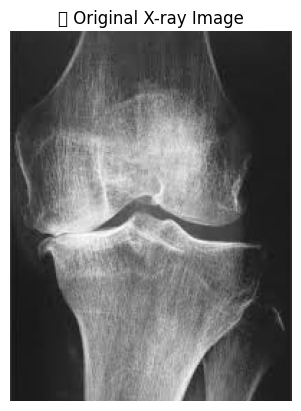


🧠 PREDICTION SUMMARY
✅ KL Grade: 4
📏 Estimated Joint Space Width: 1.00 mm
🦴 Ahlbäck Grade: 5
📉 Estimated Bone Loss: > 10 mm
📖 Description: Severe bone collapse and deformity.


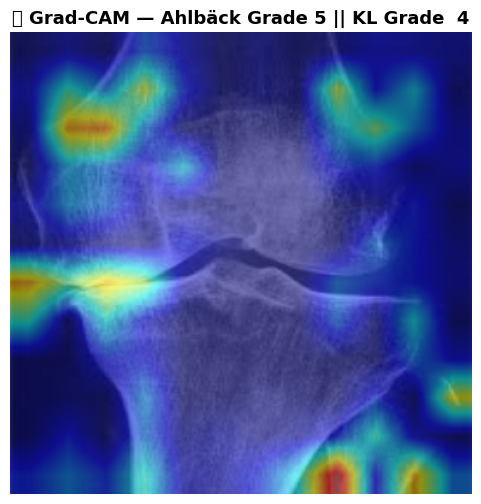


🦴 Common Symptoms Observed in Knee Osteoarthritis
  • Pain or discomfort during movement or after long periods of activity.
  • Morning stiffness or stiffness after inactivity.
  • Swelling or warmth around the knee joint.
  • Crackling, grinding, or clicking sounds when moving the knee.
  • Difficulty bending, squatting, or fully straightening the leg.

📘 KL Grade 4 Interpretation
---------------------------------------------
  🩻 Stage: Severe joint space loss; bone sclerosis.
  💊 Recommended Treatment:
    - Consult orthopedic surgeon.
    - Pain management plan.
  ⚠️ Precautions:
    - Avoid weight-bearing stress.
    - Use walking aids.

📗 Ahlbäck Grade 5 Interpretation
---------------------------------------------
  🦴 Severity: Grade V — >10 mm bone loss with deformity.
  💊 Recommended Treatment:
    - Total knee replacement.
    - Post-surgery rehab.
  ⚠️ Precautions:
    - Avoid risky movements; modify home.

✅ Interpretation complete. Always consult an orthopedic specialist fo

In [62]:
# ===============================================
# 🩻 CELL 2 — Run Prediction Report
# ===============================================

# ⚙️ Path to test image
image_path = r"/content/drive/MyDrive/images.jpeg"

# ✅ Run the complete report
run_knee_report(image_path, model, device)


In [70]:
# ===============================================
# 🧠 CELL 1 — Setup: Prediction + GradCAM + Report (Enhanced)
# ===============================================

import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# ======================================================
# 🩻 Preprocessing (match your training transforms)
# ======================================================
test_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ======================================================
# 📊 Mapping functions
# ======================================================
def kl_to_jsw(kl_grade):
    mapping = {0: 5.0, 1: 4.0, 2: 3.0, 3: 2.0, 4: 1.0}
    return mapping.get(kl_grade, 2.5)

def ahlback_to_boneloss(ahl_grade):
    mapping = {
        1: ("< 3 mm", "Minimal narrowing, no visible bone loss."),
        2: ("≈ 3–5 mm", "Complete cartilage loss, early bone contact."),
        3: ("≈ 5 mm", "Mild bone attrition / early erosion."),
        4: ("≈ 7 mm", "Moderate bone loss and flattening."),
        5: ("> 10 mm", "Severe bone collapse and deformity.")
    }
    return mapping.get(ahl_grade, ("–", "Undefined."))

# ======================================================
# 🔥 Grad-CAM Function (JET color)
# ======================================================
def generate_gradcam(model, image_tensor, target_layer, branch="ahlback", class_index=0):
    model.eval()
    gradients, activations = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])
    def forward_hook(module, input, output):
        activations.append(output)

    h_b = target_layer.register_backward_hook(backward_hook)
    h_f = target_layer.register_forward_hook(forward_hook)

    kl_out, ahl_out = model(image_tensor)
    output = ahl_out if branch == "ahlback" else kl_out
    class_score = output[:, class_index]

    model.zero_grad()
    class_score.backward()

    grads = gradients[0].detach()
    acts = activations[0].detach()
    pooled_grads = torch.mean(grads, dim=[0, 2, 3])
    for i in range(acts.shape[1]):
        acts[:, i, :, :] *= pooled_grads[i]

    heatmap = acts.sum(dim=1).squeeze()
    heatmap = F.relu(heatmap)
    heatmap /= heatmap.max()
    heatmap = heatmap.cpu().numpy()
    heatmap = cv2.resize(heatmap, (384, 384))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    overlayed = cv2.addWeighted(img, 0.5, heatmap_color, 0.5, 0)
    h_b.remove(); h_f.remove()
    return overlayed

# ======================================================
# 🩺 Clinical Interpretation
# ======================================================
def describe_joint_condition(kl_grade, ahlback_grade):
    symptoms = [
        "Pain or discomfort during movement or after long periods of activity.",
        "Morning stiffness or stiffness after inactivity.",
        "Swelling or warmth around the knee joint.",
        "Crackling, grinding, or clicking sounds when moving the knee.",
        "Difficulty bending, squatting, or fully straightening the leg."
    ]

    kl_descriptions = {
        0: {"stage": "No radiographic signs of osteoarthritis.",
            "treatment": ["Maintain an active lifestyle.", "Keep healthy weight."],
            "precautions": ["Avoid high-impact activities."]},
        1: {"stage": "Doubtful joint space narrowing; possible small osteophytes.",
            "treatment": ["Start mild physiotherapy.", "Flexibility and balance exercises."],
            "precautions": ["Avoid repetitive stress on joints."]},
        2: {"stage": "Definite osteophytes and early joint space narrowing.",
            "treatment": ["Use mild pain relief.", "Low-impact workouts (cycling, swimming).", "Use ice packs if inflamed."],
            "precautions": ["Avoid overexertion; monitor symptoms."]},
        3: {"stage": "Moderate joint space reduction with multiple osteophytes.",
            "treatment": ["Injections (corticosteroids).", "Targeted physiotherapy.", "Knee braces for support."],
            "precautions": ["Limit stairs; use supports for long walks."]},
        4: {"stage": "Severe joint space loss; bone sclerosis.",
            "treatment": ["Consult orthopedic surgeon.", "Pain management plan."],
            "precautions": ["Avoid weight-bearing stress.", "Use walking aids."]}
    }

    ahl_descriptions = {
        1: {"severity": "Grade I — <3 mm joint space narrowing, no bone loss.",
            "treatment": ["Light physiotherapy.", "Anti-inflammatory medication."],
            "precautions": ["Avoid running/jumping."]},
        2: {"severity": "Grade II — Complete space loss, no collapse.",
            "treatment": ["Pain relief injections.", "ROM exercises."],
            "precautions": ["Limit stair use; avoid overload."]},
        3: {"severity": "Grade III — Bone loss <5 mm; early attrition.",
            "treatment": ["Supportive devices.", "Rehab and stabilization therapy."],
            "precautions": ["Avoid squatting; take rest breaks."]},
        4: {"severity": "Grade IV — 5–10 mm bone loss (moderate).",
            "treatment": ["Orthopedic consultation.", "Walking aids (cane/walker)."],
            "precautions": ["Rest intervals; avoid hard surfaces."]},
        5: {"severity": "Grade V — >10 mm bone loss with deformity.",
            "treatment": ["Total knee replacement.", "Post-surgery rehab."],
            "precautions": ["Avoid risky movements; modify home."]}
    }

    print("\n=======================================================")
    print("🦴 Common Symptoms Observed in Knee Osteoarthritis")
    print("=======================================================")
    for s in symptoms: print(f"  • {s}")

    if kl_grade in kl_descriptions:
        info = kl_descriptions[kl_grade]
        print(f"\n📘 KL Grade {kl_grade} Interpretation")
        print("---------------------------------------------")
        print(f"  🩻 Stage: {info['stage']}")
        print(f"  💊 Recommended Treatment:")
        for t in info["treatment"]: print(f"    - {t}")
        print(f"  ⚠️ Precautions:")
        for p in info["precautions"]: print(f"    - {p}")

    if ahlback_grade in ahl_descriptions:
        info = ahl_descriptions[ahlback_grade]
        print(f"\n📗 Ahlbäck Grade {ahlback_grade} Interpretation")
        print("---------------------------------------------")
        print(f"  🦴 Severity: {info['severity']}")
        print(f"  💊 Recommended Treatment:")
        for t in info["treatment"]: print(f"    - {t}")
        print(f"  ⚠️ Precautions:")
        for p in info["precautions"]: print(f"    - {p}")

    print("\n✅ Interpretation complete. Always consult an orthopedic specialist for personalized evaluation.")
    print("=======================================================\n")

# ======================================================
# 🧠 Master Function — Complete Prediction & Report (with confidence)
# ======================================================
def run_knee_report(image_path, model, device):
    img = Image.open(image_path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.title("🩻 Original X-ray Image")
    plt.show()

    # Preprocess
    input_tensor = test_transform(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        kl_out, ahl_out = model(input_tensor)
        kl_pred = kl_out.argmax(dim=1).item()
        ahl_pred = ahl_out.argmax(dim=1).item() + 1
        probs_kl = torch.softmax(kl_out, dim=1)[0].cpu().numpy()
        probs_ahl = torch.softmax(ahl_out, dim=1)[0].cpu().numpy()

    jsw = kl_to_jsw(kl_pred)
    bone_loss, desc = ahlback_to_boneloss(ahl_pred)

    print("\n===============================")
    print("🧠 PREDICTION SUMMARY")
    print("===============================")
    print(f"✅ KL Grade: {kl_pred} ({probs_kl[kl_pred]*100:.2f}% confidence)")
    print(f"📏 Estimated Joint Space Width: {jsw:.2f} mm")
    print(f"🦴 Ahlbäck Grade: {ahl_pred} ({probs_ahl[ahl_pred-1]*100:.2f}% confidence)")
    print(f"📉 Estimated Bone Loss: {bone_loss}")
    print(f"📖 Description: {desc}")
    print("===============================")

    # 🧩 AI Summary
    print(f"\n💬 AI Summary: The model predicts KL Grade {kl_pred} and Ahlbäck Grade {ahl_pred} "
          f"with confidence levels of {probs_kl[kl_pred]*100:.1f}% and {probs_ahl[ahl_pred-1]*100:.1f}%. "
          f"Estimated JSW ≈ {jsw:.2f} mm and bone loss {bone_loss.lower()} ({desc.lower()}).")

    # Grad-CAM
    target_layer = model.resnet.layer4[-1]
    gradcam = generate_gradcam(model, input_tensor, target_layer, branch="ahlback", class_index=ahl_pred-1)
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(gradcam, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"🔥 Grad-CAM — Ahlbäck Grade {ahl_pred} || KL Grade {kl_pred}",
              fontsize=13, weight='bold')
    plt.show()

    # Clinical interpretation
    describe_joint_condition(kl_pred, ahl_pred)


🩻 KNEE OSTEOARTHRITIS AI DIAGNOSTIC REPORT
📂 Loaded Image From: /content/drive/MyDrive/2_3 test image.png
-----------------------------------------------


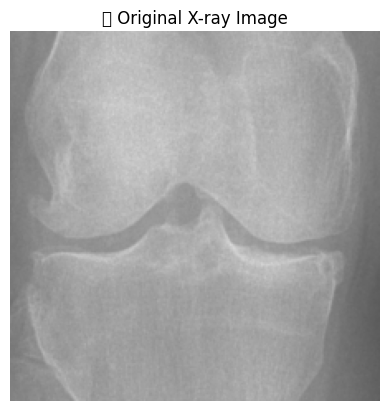


🧠 PREDICTION SUMMARY
✅ KL Grade: 2 (93.81% confidence)
📏 Estimated Joint Space Width: 3.00 mm
🦴 Ahlbäck Grade: 3 (93.90% confidence)
📉 Estimated Bone Loss: ≈ 5 mm
📖 Description: Mild bone attrition / early erosion.

💬 AI Summary: The model predicts KL Grade 2 and Ahlbäck Grade 3 with confidence levels of 93.8% and 93.9%. Estimated JSW ≈ 3.00 mm and bone loss ≈ 5 mm (mild bone attrition / early erosion.).


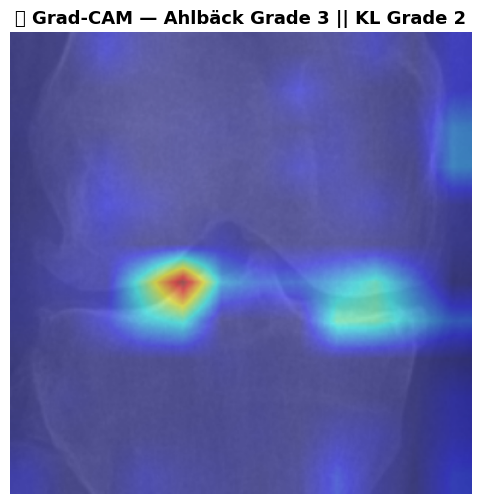


🦴 Common Symptoms Observed in Knee Osteoarthritis
  • Pain or discomfort during movement or after long periods of activity.
  • Morning stiffness or stiffness after inactivity.
  • Swelling or warmth around the knee joint.
  • Crackling, grinding, or clicking sounds when moving the knee.
  • Difficulty bending, squatting, or fully straightening the leg.

📘 KL Grade 2 Interpretation
---------------------------------------------
  🩻 Stage: Definite osteophytes and early joint space narrowing.
  💊 Recommended Treatment:
    - Use mild pain relief.
    - Low-impact workouts (cycling, swimming).
    - Use ice packs if inflamed.
  ⚠️ Precautions:
    - Avoid overexertion; monitor symptoms.

📗 Ahlbäck Grade 3 Interpretation
---------------------------------------------
  🦴 Severity: Grade III — Bone loss <5 mm; early attrition.
  💊 Recommended Treatment:
    - Supportive devices.
    - Rehab and stabilization therapy.
  ⚠️ Precautions:
    - Avoid squatting; take rest breaks.

✅ Interpretati

In [71]:
# ===============================================
# 🩻 CELL 2 — Run Prediction Report + Visualization
# ===============================================

# ⚙️ Path to test X-ray image (update if needed)
# Example: r"/content/drive/MyDrive/images.jpeg"
image_path = r"/content/drive/MyDrive/2_3 test image.png"

print("===============================================")
print("🩻 KNEE OSTEOARTHRITIS AI DIAGNOSTIC REPORT")
print("===============================================")
print(f"📂 Loaded Image From: {image_path}")
print("-----------------------------------------------")

# ✅ Run complete prediction + Grad-CAM + AI summary
try:
    run_knee_report(image_path, model, device)
    print("-----------------------------------------------")
    print("✅ Report Generated Successfully!")
    print("📊 Includes:")
    print("   • Original X-ray display")
    print("   • KL & Ahlbäck grade predictions with confidence")
    print("   • Grad-CAM visualization overlay (JET color)")
    print("   • Detailed clinical interpretation")
    print("===============================================")

except FileNotFoundError:
    print("❌ Error: Image file not found.")
    print("💡 Please check your file path or upload the image again.")
except NameError:
    print("❌ Error: Model or device not found.")
    print("💡 Please ensure you’ve executed CELL 1 successfully.")
except Exception as e:
    print("⚠️ Unexpected Error Occurred:")
    print(e)
    print("💬 Try rerunning the setup cell or verify your model checkpoint.")
